#**Chapter 2 – End-to-end Machine Learning project**

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

*This notebook contains all the sample code and solutions to the exercices in chapter 2.*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1h3MYMweTUCuJx14Ea49QjP1zk20O1Maw#scrollTo=vHY6AtN82VHk)

# Setup

First, let's connect the notebook with Google Drive, so we will be able to load or store files, models, data, etc.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Now, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20.

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Get the Data

## Download the Data

How the next chunks work is not important at this moment, just run them to get the data fetched.

In [3]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [4]:
fetch_housing_data()

In [5]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

Finally, load the data

In [6]:
housing = load_housing_data()

In [7]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Take a Quick Look at the Data Structure

In [8]:

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [10]:
housing["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Saving figure attribute_histogram_plots


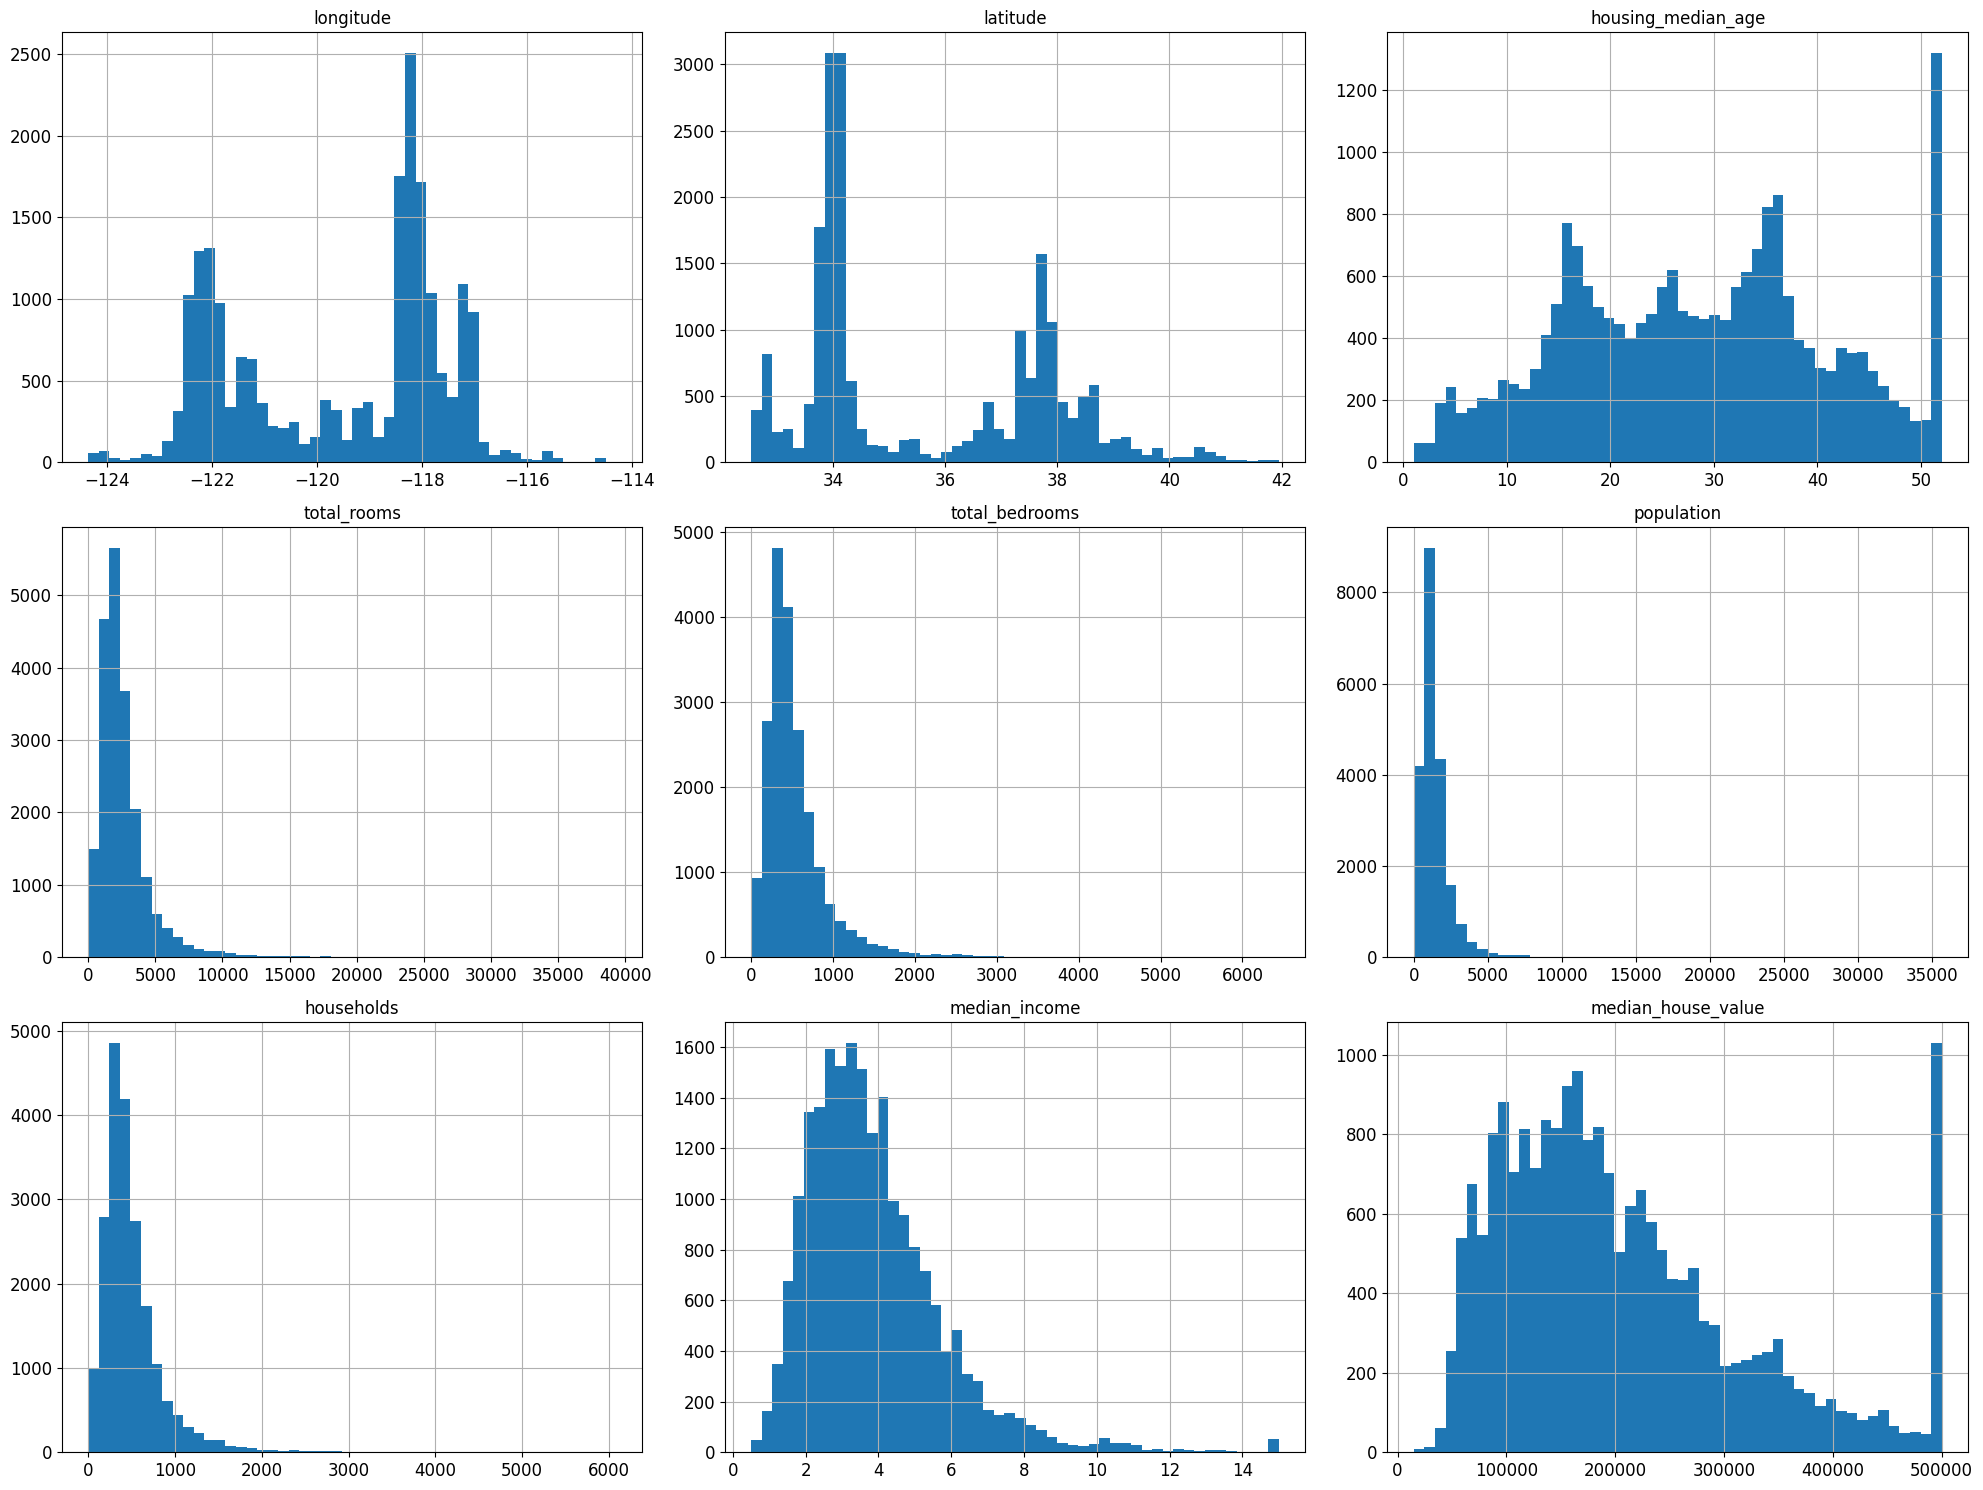

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

## Create a Test Set

In [13]:
# to make this notebook's output identical at every run
np.random.seed(1812) # Tchaikovsky's Overture :)



---



Just run these chunks, we will use the `train_test_split()` from sklearn, these are just for illustrational purposes

In [14]:
# import numpy as np

# # For illustration only. Sklearn has train_test_split()
# def split_train_test(data, test_ratio):
#     shuffled_indices = np.random.permutation(len(data))
#     test_set_size = int(len(data) * test_ratio)
#     test_indices = shuffled_indices[:test_set_size]
#     train_indices = shuffled_indices[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

In [15]:
# train_set, test_set = split_train_test(housing, 0.2)
# len(train_set)

In [16]:
#len(test_set)

In [17]:
# from zlib import crc32

# def test_set_check(identifier, test_ratio):
#     return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

# def split_train_test_by_id(data, test_ratio, id_column):
#     ids = data[id_column]
#     in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
#     return data.loc[~in_test_set], data.loc[in_test_set]

The implementation of `test_set_check()` above works fine in both Python 2 and Python 3. In earlier releases, the following implementation was proposed, which supported any hash function, but was much slower and did not support Python 2:

In [18]:
# import hashlib

# def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    # return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

If you want an implementation that supports any hash function and is compatible with both Python 2 and Python 3, here is one:

In [19]:
# def test_set_check(identifier, test_ratio, hash=hashlib.md5):
#     return bytearray(hash(np.int64(identifier)).digest())[-1] < 256 * test_ratio

In [20]:
# housing_with_id = housing.reset_index()   # adds an `index` column
# train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [21]:
# housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
# train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [22]:
# test_set.head()



---



THIS is what we will be using

In [23]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=1812)

In [24]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6872,-118.09,34.07,38.0,1036.0,226.0,1058.0,235.0,3.2578,184200.0,<1H OCEAN
17184,-122.49,37.50,21.0,1209.0,309.0,801.0,259.0,4.5625,500000.0,NEAR OCEAN
1461,-121.99,37.97,30.0,3320.0,589.0,1470.0,543.0,4.6071,184100.0,INLAND
1507,-122.05,37.93,15.0,7803.0,1603.0,2957.0,1546.0,4.4500,184900.0,NEAR BAY
17650,-121.88,37.26,25.0,3025.0,689.0,1755.0,661.0,3.8893,218600.0,<1H OCEAN


Now, you may want to perform some adjustments to certain variable. For instance, We don't have enough instances (observations, data...) for the districts that are above a median income equal to 6, as the following plot shows:

<Axes: >

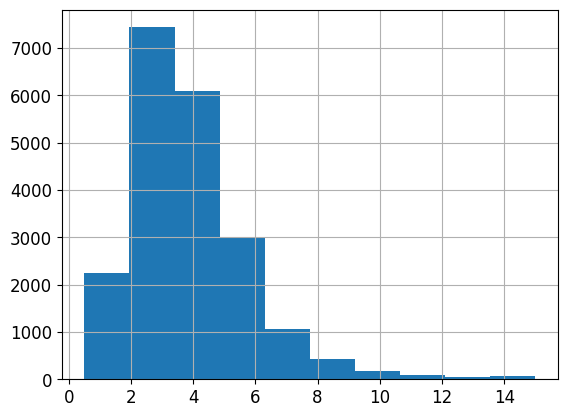

In [25]:
housing["median_income"].hist()

In [26]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [27]:
housing["income_cat"].value_counts()

3    7236
2    6581
4    3639
5    2362
1     822
Name: income_cat, dtype: int64

<Axes: >

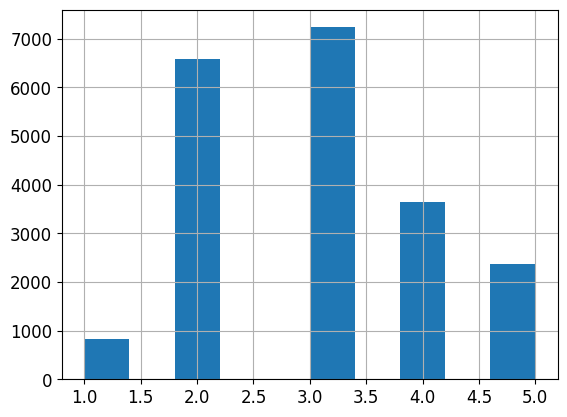

In [28]:
housing["income_cat"].hist()

One may also want to stratify a sample; i.e, preserving the proportion of samples in each class (in this case, according to *income_cat*).

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=1812)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

Shares in the testing set.

In [30]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: income_cat, dtype: float64

Sahres in the training set. They do coincide, stratification process has been correct.

In [31]:
housing["income_cat"].value_counts() / len(housing)

3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: income_cat, dtype: float64

This is just a fancy way to calculate the shares and see how much they diverge.

In [32]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=1812)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [33]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
1,0.039826,0.039971,0.038033,-4.501217,0.364964
2,0.318847,0.318798,0.332607,4.315454,-0.015195
3,0.350581,0.350533,0.347384,-0.912106,-0.013820
4,0.176308,0.176357,0.169574,-3.819731,0.027480
5,0.114438,0.114341,0.112403,-1.778154,-0.084674


In [34]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Discover and Visualize the Data to Gain Insights

Let's just make a copy of the training set and call it *housing*.

In [35]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

Saving figure bad_visualization_plot


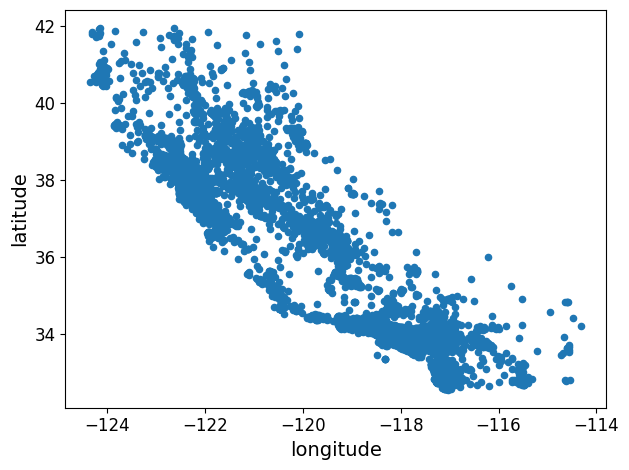

In [36]:
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

A bot more elaborated...

Saving figure housing_prices_scatterplot


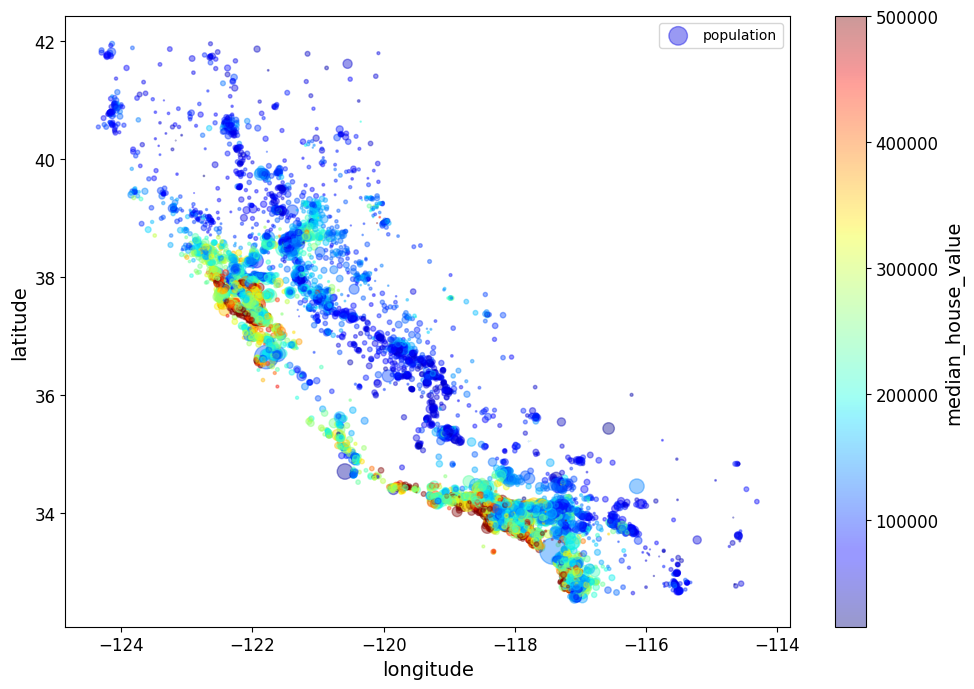

In [37]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()
save_fig("housing_prices_scatterplot")

A bit more...

In [38]:
# Download the California image
images_path = os.path.join(PROJECT_ROOT_DIR, "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('./images/end_to_end_project/california.png',
 <http.client.HTTPMessage at 0x7ea6b62ab3a0>)

Saving figure california_housing_prices_plot


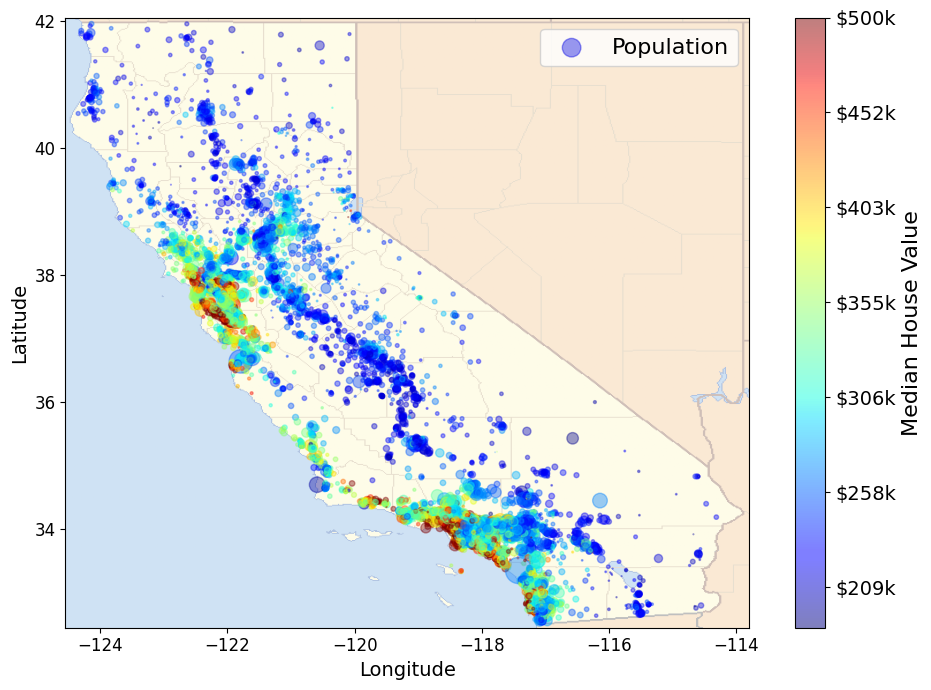

In [39]:
import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join(images_path, filename))
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=housing['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

## Looking for Correlations

In [40]:
corr_matrix = housing.corr()

<ipython-input-40-bac487469033>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr()


In [41]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.685270
total_rooms           0.135420
housing_median_age    0.102589
households            0.065370
total_bedrooms        0.050006
population           -0.025827
longitude            -0.048957
latitude             -0.139718
Name: median_house_value, dtype: float64

Saving figure scatter_matrix_plot


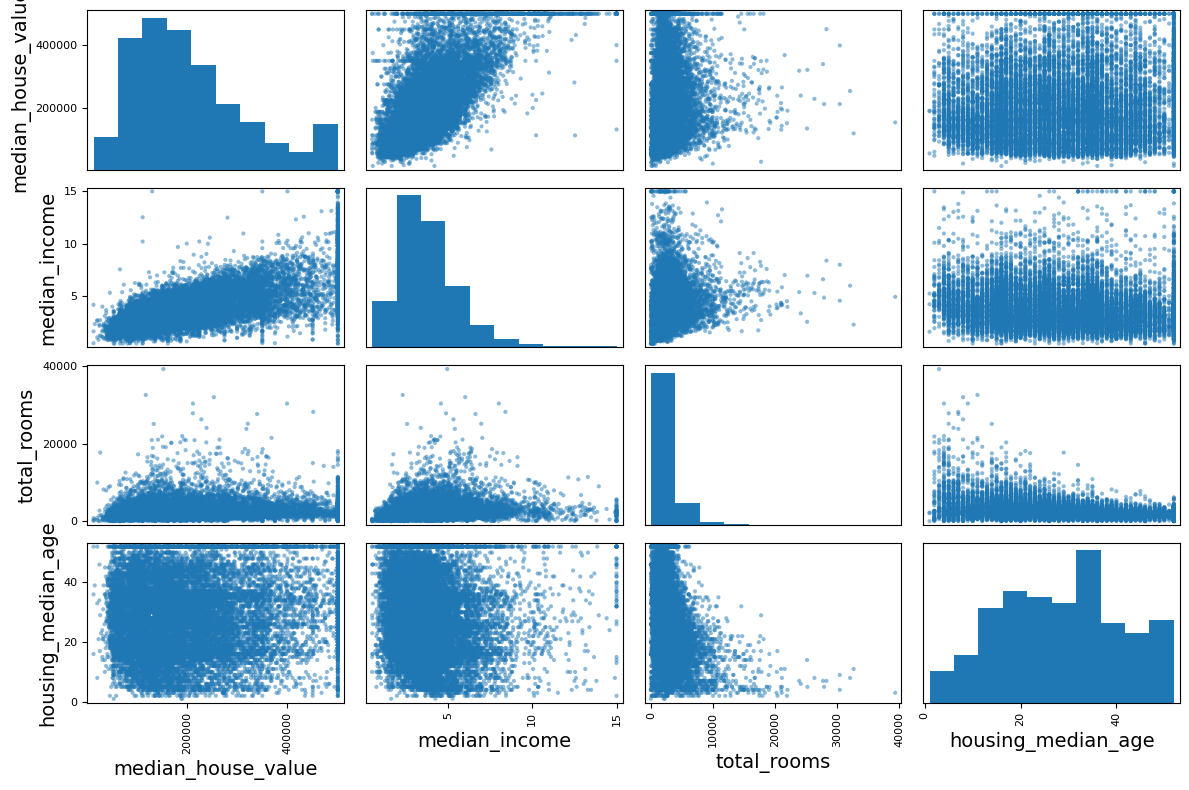

In [42]:
# from pandas.tools.plotting import scatter_matrix # For older versions of Pandas
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")

Saving figure income_vs_house_value_scatterplot


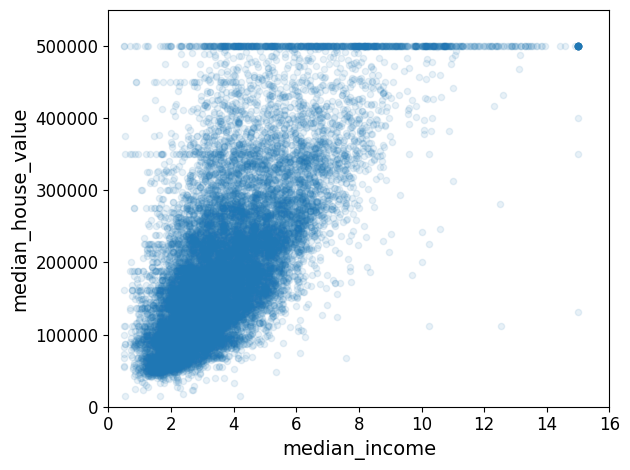

In [43]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)
plt.axis([0, 16, 0, 550000])
save_fig("income_vs_house_value_scatterplot")

## Experimenting with Attribute Combinations

In [44]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [45]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

<ipython-input-45-51a0e6bf2eb4>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr()


median_house_value          1.000000
median_income               0.685270
rooms_per_household         0.156199
total_rooms                 0.135420
housing_median_age          0.102589
households                  0.065370
total_bedrooms              0.050006
population                 -0.025827
population_per_household   -0.038437
longitude                  -0.048957
latitude                   -0.139718
bedrooms_per_room          -0.257057
Name: median_house_value, dtype: float64

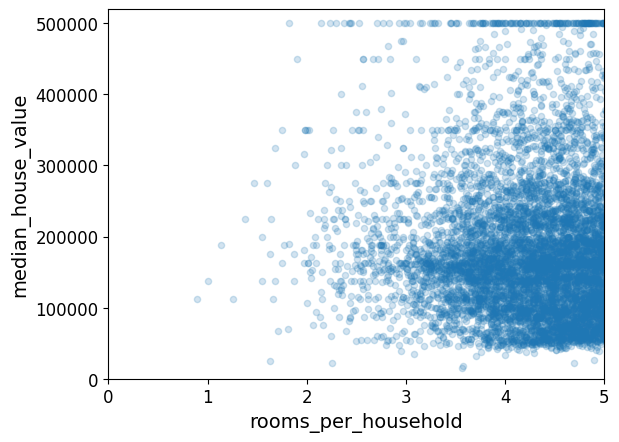

In [46]:
housing.plot(kind="scatter", x="rooms_per_household", y="median_house_value",
             alpha=0.2)
plt.axis([0, 5, 0, 520000])
plt.show()

In [47]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,16512.000000,16512.000000,16512.000000,16512.000000,16343.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16343.000000,16512.000000
mean,-119.562531,35.620896,28.630875,2637.598292,538.740378,1429.308018,500.400436,3.869509,207220.989099,5.426053,0.213131,2.994682
std,2.002863,2.136138,12.599122,2179.477144,422.842587,1145.314216,383.702790,1.903066,115250.262569,2.516875,0.057919,4.457629
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.888889,0.100000,0.750000
25%,-121.790000,33.930000,18.000000,1454.000000,297.000000,790.750000,281.000000,2.560825,120100.000000,4.436645,0.175223,2.430613
50%,-118.480000,34.250000,29.000000,2129.000000,436.000000,1170.000000,410.000000,3.539100,180400.000000,5.223967,0.203451,2.818868
75%,-118.010000,37.710000,37.000000,3145.000000,647.000000,1726.000000,605.000000,4.740575,265125.000000,6.062902,0.239849,3.285976
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,502.461538


# Prepare the Data for Machine Learning Algorithms

Separate the labels and the features.

In [48]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

How to deal with NA. There are several options:

```python
housing.dropna(subset=["total_bedrooms"])    # option 1
housing.drop("total_bedrooms", axis=1)       # option 2
median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

To demonstrate each of them, let's create a copy of the housing dataset, but keeping only the rows that contain at least one null. Then it will be easier to visualize exactly what each option does:

In [49]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN
3778,-118.40,34.17,24.0,6347.0,NaN,2945.0,1492.0,3.3545,<1H OCEAN
5059,-118.35,34.01,35.0,3776.0,NaN,1583.0,749.0,3.5486,<1H OCEAN
9620,-120.40,37.30,28.0,1401.0,NaN,967.0,257.0,1.5917,INLAND
10761,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [50]:
sample_incomplete_rows.dropna(subset=["total_bedrooms"])    # option 1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [51]:
sample_incomplete_rows.drop("total_bedrooms", axis=1)       # option 2

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
4186,-118.23,34.13,48.0,1308.0,835.0,294.0,4.2891,<1H OCEAN
3778,-118.40,34.17,24.0,6347.0,2945.0,1492.0,3.3545,<1H OCEAN
5059,-118.35,34.01,35.0,3776.0,1583.0,749.0,3.5486,<1H OCEAN
9620,-120.40,37.30,28.0,1401.0,967.0,257.0,1.5917,INLAND
10761,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [52]:
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3

In [53]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
4186,-118.23,34.13,48.0,1308.0,436.0,835.0,294.0,4.2891,<1H OCEAN
3778,-118.40,34.17,24.0,6347.0,436.0,2945.0,1492.0,3.3545,<1H OCEAN
5059,-118.35,34.01,35.0,3776.0,436.0,1583.0,749.0,3.5486,<1H OCEAN
9620,-120.40,37.30,28.0,1401.0,436.0,967.0,257.0,1.5917,INLAND
10761,-117.87,33.62,8.0,1266.0,436.0,375.0,183.0,9.8020,<1H OCEAN


There are also tools to impute certain statistics.

In [54]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

Remove the text attribute because median can only be calculated on numerical attributes:

In [55]:
housing_num = housing.drop("ocean_proximity", axis=1)
# alternatively: housing_num = housing.select_dtypes(include=[np.number])

In [56]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [57]:
imputer.statistics_

array([-118.48  ,   34.25  ,   29.    , 2129.    ,  436.    , 1170.    ,
        410.    ,    3.5391])

Transform the training set:

In [58]:
#
X = imputer.transform(housing_num)

In [59]:
#housing_tr = pd.DataFrame(X, columns=housing_num.columns,
#                          index=housing.index)

In [60]:
#housing_tr.loc[sample_incomplete_rows.index.values]

In [61]:
#imputer.strategy

In [62]:
#housing_tr = pd.DataFrame(X, columns=housing_num.columns,
#                          index=housing_num.index)

In [63]:
#housing_tr.head()

## Handling Text and Categorical Attributes

Now let's preprocess the categorical input feature, `ocean_proximity`:

In [64]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
19815,INLAND
12313,INLAND
3866,<1H OCEAN
19074,<1H OCEAN
5836,<1H OCEAN
14569,NEAR OCEAN
16614,NEAR OCEAN
506,NEAR BAY
16727,<1H OCEAN
3967,<1H OCEAN


In [65]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [4.],
       [4.],
       [3.],
       [0.],
       [0.]])

In [66]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

We mainly use One-hot encoder:

In [67]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [68]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

In [69]:
cat_encoder = OneHotEncoder(sparse=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [70]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Custom Transformers (SKIP THIS)

Let's create a custom transformer to add extra attributes:

In [71]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

Note that I hard coded the indices (3, 4, 5, 6) for concision and clarity in the book, but it would be much cleaner to get them dynamically, like this:

In [72]:
col_names = "total_rooms", "total_bedrooms", "population", "households"
rooms_ix, bedrooms_ix, population_ix, households_ix = [
    housing.columns.get_loc(c) for c in col_names] # get the column indices

Also, `housing_extra_attribs` is a NumPy array, we've lost the column names (unfortunately, that's a problem with Scikit-Learn). To recover a `DataFrame`, you could run this:

In [73]:
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs,
    columns=list(housing.columns)+["rooms_per_household", "population_per_household"],
    index=housing.index)
housing_extra_attribs.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household
19815,-119.28,36.54,33.0,1470.0,330.0,1222.0,301.0,1.8163,INLAND,4.883721,4.059801
12313,-116.57,33.64,10.0,489.0,82.0,183.0,74.0,6.2702,INLAND,6.608108,2.472973
3866,-118.46,34.17,24.0,2814.0,675.0,1463.0,620.0,4.1875,<1H OCEAN,4.53871,2.359677
19074,-122.49,38.3,14.0,2844.0,602.0,1613.0,544.0,3.3571,<1H OCEAN,5.227941,2.965074
5836,-118.34,34.2,41.0,2860.0,682.0,1516.0,621.0,3.0431,<1H OCEAN,4.605475,2.441224


## Transformation Pipelines

Now let's build a pipeline for preprocessing the numerical attributes. A pipeline is a predefined set of steps that take place sequenciall when invoke it.

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [75]:
housing_num_tr

array([[ 0.14106808,  0.4302775 ,  0.34679065, ..., -0.21548483,
         0.23895003,  0.16349783],
       [ 1.49417214, -0.92735379, -1.47878862, ...,  0.46966606,
        -0.11704099, -0.70626908],
       [ 0.55049441, -0.67923497, -0.36756646, ..., -0.35256817,
        -0.14245786,  0.39904082],
       ...,
       [-1.22701499,  0.63158145,  0.82302872, ..., -0.76331178,
        -0.16650774,  1.49133956],
       [ 0.78516559, -0.89458338, -0.76443152, ..., -0.22140864,
         0.02284966,  0.51714844],
       [ 0.75520757, -0.76818323,  0.98177474, ..., -0.72350817,
         0.00349389,  1.38728107]])

In [76]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

housing_prepared = full_pipeline.fit_transform(housing)

In [77]:
housing_prepared

array([[ 0.14106808,  0.4302775 ,  0.34679065, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.49417214, -0.92735379, -1.47878862, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.55049441, -0.67923497, -0.36756646, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.22701499,  0.63158145,  0.82302872, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.78516559, -0.89458338, -0.76443152, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.75520757, -0.76818323,  0.98177474, ...,  0.        ,
         0.        ,  0.        ]])

In [78]:
housing_prepared.shape

(16512, 16)

For reference, here is the old solution based on a `DataFrameSelector` transformer (to just select a subset of the Pandas `DataFrame` columns), and a `FeatureUnion`:

In [79]:
# from sklearn.base import BaseEstimator, TransformerMixin

# # Create a class to select numerical or categorical columns
# class OldDataFrameSelector(BaseEstimator, TransformerMixin):
#     def __init__(self, attribute_names):
#         self.attribute_names = attribute_names
#     def fit(self, X, y=None):
#         return self
#     def transform(self, X):
#         return X[self.attribute_names].values

Now let's join all these components into a big pipeline that will preprocess both the numerical and the categorical features:

In [80]:
# num_attribs = list(housing_num)
# cat_attribs = ["ocean_proximity"]

# old_num_pipeline = Pipeline([
#         ('selector', OldDataFrameSelector(num_attribs)),
#         ('imputer', SimpleImputer(strategy="median")),
#         ('attribs_adder', CombinedAttributesAdder()),
#         ('std_scaler', StandardScaler()),
#     ])

# old_cat_pipeline = Pipeline([
#         ('selector', OldDataFrameSelector(cat_attribs)),
#         ('cat_encoder', OneHotEncoder(sparse=False)),
#     ])

In [81]:
# from sklearn.pipeline import FeatureUnion

# old_full_pipeline = FeatureUnion(transformer_list=[
#         ("num_pipeline", old_num_pipeline),
#         ("cat_pipeline", old_cat_pipeline),
#     ])

In [82]:
# old_housing_prepared = old_full_pipeline.fit_transform(housing)
# old_housing_prepared

The result is the same as with the `ColumnTransformer`:

In [83]:
# np.allclose(housing_prepared, old_housing_prepared)

# Select and Train a Model

## Training and Evaluating on the Training Set

In [84]:
housing_prepared

array([[ 0.14106808,  0.4302775 ,  0.34679065, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.49417214, -0.92735379, -1.47878862, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.55049441, -0.67923497, -0.36756646, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.22701499,  0.63158145,  0.82302872, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.78516559, -0.89458338, -0.76443152, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.75520757, -0.76818323,  0.98177474, ...,  0.        ,
         0.        ,  0.        ]])

In [85]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

Compare against the actual values:

In [86]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

68809.85493818442

**Note**: since Scikit-Learn 0.22, you can get the RMSE directly by calling the `mean_squared_error()` function with `squared=False`.

In [87]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

49670.23200370594

In [88]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=1812)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(random_state=1812)

In [89]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

## Better Evaluation Using Cross-Validation (will see this in Topic 3!)

In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [91]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [69668.61384268 68046.44687982 72163.02814419 72263.7481141
 73687.66845886 75458.83460202 71434.25851825 69836.1932793
 73024.35282535 70042.23281534]
Mean: 71562.53774799225
Standard deviation: 2096.2916865935595


In [92]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [65714.87279108 68185.41840036 71376.93644487 68549.91062436
 68894.24830472 68823.34597382 70207.09051179 66402.33264289
 74015.09905905 69782.9815218 ]
Mean: 69195.22362747302
Standard deviation: 2256.9559261649374


**Note**: we specify `n_estimators=100` to be future-proof since the default value is going to change to 100 in Scikit-Learn 0.22 (for simplicity, this is not shown in the book).

In [93]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=1812)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=1812)

In [94]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

18745.155284917375

In [95]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [46409.8630742  48323.76301017 51883.72532093 49396.03454542
 52942.22414092 52219.37782419 52713.6415471  47545.00156341
 51513.47829167 52292.52187046]
Mean: 50523.96311884759
Standard deviation: 2266.851056106399


In [96]:
scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

count       10.000000
mean     69195.223627
std       2379.040435
min      65714.872791
25%      68276.541456
50%      68858.797139
75%      70101.063264
max      74015.099059
dtype: float64

In [97]:
from sklearn.svm import SVR

svm_reg = SVR(kernel="linear")
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

110564.78515628999

# Fine-Tune Your Model (we'll see this in Topic 3, too!)



## Grid Search

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=1812)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1812),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

The best hyperparameter combination found:

In [99]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [100]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30, random_state=1812)

Let's look at the score of each hyperparameter combination tested during the grid search:

In [101]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

63926.33066838959 {'max_features': 2, 'n_estimators': 3}
56157.357358894755 {'max_features': 2, 'n_estimators': 10}
53357.47364498762 {'max_features': 2, 'n_estimators': 30}
61425.85063625896 {'max_features': 4, 'n_estimators': 3}
53792.73924953228 {'max_features': 4, 'n_estimators': 10}
51085.7653395275 {'max_features': 4, 'n_estimators': 30}
60232.82386988491 {'max_features': 6, 'n_estimators': 3}
52835.13562391016 {'max_features': 6, 'n_estimators': 10}
50658.84945827999 {'max_features': 6, 'n_estimators': 30}
59803.955822092285 {'max_features': 8, 'n_estimators': 3}
52519.74569767969 {'max_features': 8, 'n_estimators': 10}
50097.88946560656 {'max_features': 8, 'n_estimators': 30}
63167.3176742827 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
55361.235326864546 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60147.293562739076 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
53242.85198762505 {'bootstrap': False, 'max_features': 3, 'n_estimators': 

In [102]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.080385,0.002818,0.004538,0.000058,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-4.095154e+09,-3.935518e+09,...,-4.086576e+09,1.061994e+08,18,-1.161279e+09,-1.060750e+09,-1.055492e+09,-1.082401e+09,-1.089912e+09,-1.089967e+09,3.790754e+07
1,0.257239,0.004125,0.011967,0.000297,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-2.977166e+09,-3.039134e+09,...,-3.153649e+09,1.417209e+08,11,-6.225342e+08,-5.798697e+08,-5.699728e+08,-5.861330e+08,-5.867725e+08,-5.890564e+08,1.779385e+07
2,1.022306,0.182893,0.042133,0.005464,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.656965e+09,-2.824628e+09,...,-2.847020e+09,1.261895e+08,8,-4.604028e+08,-4.355675e+08,-4.167805e+08,-4.290344e+08,-4.317147e+08,-4.347000e+08,1.430738e+07
3,0.125830,0.002591,0.004490,0.000079,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.641794e+09,-3.670643e+09,...,-3.773135e+09,1.326169e+08,16,-1.018743e+09,-1.000261e+09,-9.646844e+08,-9.667005e+08,-9.531851e+08,-9.807147e+08,2.465537e+07
4,0.413544,0.005479,0.011775,0.000173,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.686198e+09,-2.881444e+09,...,-2.893659e+09,1.259776e+08,9,-5.496962e+08,-5.442213e+08,-5.177556e+08,-5.221285e+08,-5.240208e+08,-5.315645e+08,1.284980e+07
5,1.327308,0.140068,0.034894,0.002197,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.373219e+09,-2.607866e+09,...,-2.609755e+09,1.386858e+08,3,-4.152645e+08,-4.006333e+08,-3.869026e+08,-3.876554e+08,-3.930948e+08,-3.967101e+08,1.049671e+07
6,0.267560,0.003528,0.006045,0.001385,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.305484e+09,-3.561883e+09,...,-3.627993e+09,2.082947e+08,15,-9.732788e+08,-9.473830e+08,-9.679844e+08,-9.419404e+08,-9.614251e+08,-9.584023e+08,1.195561e+07
7,0.687242,0.131309,0.012237,0.000868,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.512896e+09,-2.791296e+09,...,-2.791552e+09,1.604326e+08,6,-5.309009e+08,-5.062542e+08,-5.074083e+08,-4.976473e+08,-5.080259e+08,-5.100473e+08,1.108216e+07
8,1.867146,0.244744,0.033875,0.002619,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.325343e+09,-2.581197e+09,...,-2.566319e+09,1.348422e+08,2,-4.030903e+08,-3.881453e+08,-3.762270e+08,-3.818419e+08,-3.783620e+08,-3.855333e+08,9.661623e+06
9,0.339158,0.007061,0.005422,0.000214,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.410364e+09,-3.483708e+09,...,-3.576513e+09,1.271015e+08,13,-9.919428e+08,-9.189548e+08,-9.042345e+08,-8.971023e+08,-8.627839e+08,-9.150037e+08,4.265812e+07


## Randomized Search

In [103]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=1812)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=1812)
rnd_search.fit(housing_prepared, housing_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1812),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ea6b1c65ab0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ea6b1c65f00>},
                   random_state=1812, scoring='neg_mean_squared_error')

In [104]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

50231.08166556464 {'max_features': 4, 'n_estimators': 56}
49823.56471134184 {'max_features': 7, 'n_estimators': 78}
79593.49621590372 {'max_features': 4, 'n_estimators': 1}
54792.313099680025 {'max_features': 1, 'n_estimators': 82}
49925.96994501794 {'max_features': 6, 'n_estimators': 68}
50105.38807382952 {'max_features': 4, 'n_estimators': 73}
49908.271410465146 {'max_features': 5, 'n_estimators': 66}
52108.58526242554 {'max_features': 7, 'n_estimators': 12}
50562.669982391904 {'max_features': 3, 'n_estimators': 117}
50499.1999502263 {'max_features': 5, 'n_estimators': 38}


## Analyze the Best Models and Their Errors

In [105]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([6.84172662e-02, 7.14905613e-02, 4.46859938e-02, 1.52776948e-02,
       1.43111480e-02, 1.59554282e-02, 1.38125734e-02, 3.39432256e-01,
       5.35513489e-02, 1.13172163e-01, 8.94473362e-02, 9.59226454e-03,
       1.44483322e-01, 1.21745923e-04, 2.23827972e-03, 4.01061845e-03])

In [106]:
# This is only to list them in order and with names

extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
#cat_encoder = cat_pipeline.named_steps["cat_encoder"] # old solution
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(0.3394322556822111, 'median_income'),
 (0.1444833222911307, 'INLAND'),
 (0.11317216278074227, 'pop_per_hhold'),
 (0.08944733617836091, 'bedrooms_per_room'),
 (0.07149056129006891, 'latitude'),
 (0.06841726616079608, 'longitude'),
 (0.05355134893183118, 'rooms_per_hhold'),
 (0.044685993759959006, 'housing_median_age'),
 (0.015955428174022023, 'population'),
 (0.015277694753227617, 'total_rooms'),
 (0.014311148007041714, 'total_bedrooms'),
 (0.013812573362787956, 'households'),
 (0.009592264538717126, '<1H OCEAN'),
 (0.004010618449256141, 'NEAR OCEAN'),
 (0.0022382797168306596, 'NEAR BAY'),
 (0.00012174592301659513, 'ISLAND')]

## Evaluate Your System on the Test Set

In [107]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [108]:
final_rmse

47469.669259187656

We can compute a 95% confidence interval for the test RMSE:

In [109]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([45440.70024842, 49415.40002961])